# Scratch — WP D2 — Do all federal states warm equally?
Copy/rename this file to `scratch_<yourname>.ipynb` and work here — not in the main file `klima_analyse.ipynb`.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
df = pd.read_csv("temp_annual_regions.csv")
de = df[["jahr", "Deutschland"]].copy()   # main series for D1, I1, I2
df.head(3)

,jahr,Brandenburg/Berlin,Brandenburg,Baden-Wuerttemberg,Bayern,Hessen,Mecklenburg-Vorpommern,Niedersachsen,Niedersachsen/Hamburg/Bremen,Nordrhein-Westfalen,Rheinland-Pfalz,Schleswig-Holstein,Saarland,Sachsen,Sachsen-Anhalt,Thueringen/Sachsen-Anhalt,Thueringen,Deutschland
0,1881,7.55,7.54,7.66,6.61,7.49,6.96,7.54,7.54,8.14,7.97,7.12,8.28,6.71,7.46,7.11,6.66,7.31
1,1882,8.99,8.97,8.08,7.33,8.25,8.54,8.88,8.88,9.03,8.55,8.78,8.79,8.12,8.81,8.35,7.77,8.34
2,1883,8.42,8.41,7.77,6.85,7.96,7.95,8.39,8.39,8.71,8.26,8.18,8.51,7.46,8.32,7.87,7.31,7.88


**Task:** Warming per region (mean 1995–2024 minus 1881–1910), median/IQR, north–south, sorted bar plot.

Template: `projekt_schritte.md` Block 3. Save figures to `../figures/` as `fig5_*.png`.

In [2]:
regions = df.columns.drop(["jahr", "Deutschland"])

past = df[df["jahr"].between(1881,1910)]
present = df[df["jahr"].between(1995,2024)]

past_mean = past[regions].mean()
present_mean = present[regions].mean()

mean = present_mean - past_mean 

In [3]:
median = mean.median()

In [4]:
q1 = mean.quantile(0.25)
q3 = mean.quantile(0.75)

iqr = q3 - q1

spread = mean.max() - mean.min()

In [5]:
mean


Brandenburg/Berlin              1.506333
Brandenburg                     1.503333
Baden-Wuerttemberg              1.566000
Bayern                          1.814333
Hessen                          1.689667
Mecklenburg-Vorpommern          1.629333
Niedersachsen                   1.714333
Niedersachsen/Hamburg/Bremen    1.712000
Nordrhein-Westfalen             1.694333
Rheinland-Pfalz                 1.802333
Schleswig-Holstein              1.568667
Saarland                        1.853333
Sachsen                         1.591333
Sachsen-Anhalt                  1.643333
Thueringen/Sachsen-Anhalt       1.689667
Thueringen                      1.740000
dtype: float64

In [6]:
north = mean[["Brandenburg/Berlin","Brandenburg", "Mecklenburg-Vorpommern", "Niedersachsen", 
                    "Niedersachsen/Hamburg/Bremen", "Nordrhein-Westfalen", "Schleswig-Holstein", "Sachsen-Anhalt", "Thueringen/Sachsen-Anhalt"]]

south = mean[["Baden-Wuerttemberg", "Bayern", "Hessen", "Rheinland-Pfalz", "Saarland", "Sachsen", "Thueringen"]]

#nicht sicher, ob die Einteilung so bleibt

north_mean = north.mean()
south_mean = south.mean()

print(north_mean)

print(south_mean)

1.6290370370370362
1.722428571428572


<Figure size 640x480 with 0 Axes>

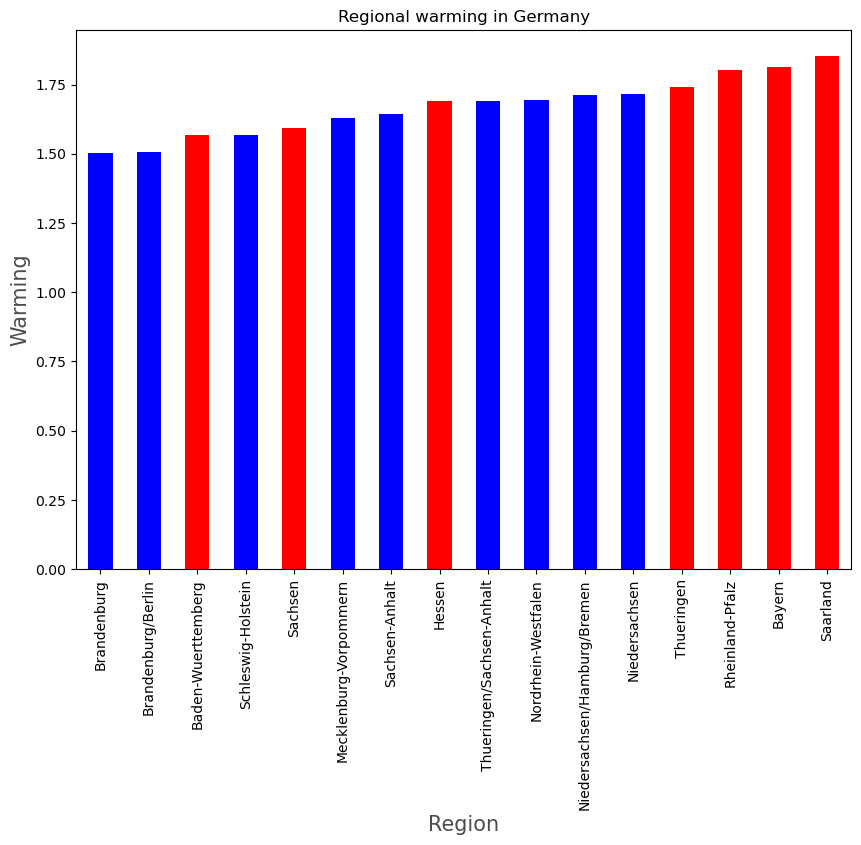

In [7]:
diff_sorted = mean.sort_values()
n_s_color = []

for i in diff_sorted.index:
    if i in north.index:
        n_s_color.append("blue")
    elif i in south.index:
        n_s_color.append("red")

plt.clf()
fig = plt.figure(figsize=(10, 7), dpi= 100, facecolor='w', edgecolor='k')
plot = fig.add_subplot(111)
diff_sorted.plot(kind = "bar", color = n_s_color)
plot.set_xlabel("Region", alpha=0.7, size=15)
plot.set_ylabel("Warming", alpha=0.7, size=15)
plot.set_title("Regional warming in Germany")
plt.show()

We compared the average temperature of 1881-1910 with the average temperature of 1995-2024 for every region.
The results show that all regions have warmed, but not much.
The spread and the interquartile range are small, that means that the warming is quite similar across Germany, 
however southern regions warmed slightly more than northern regions.